In [5]:
# Базовые библиотеки
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Статистика для временных рядов
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Машинное обучение
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
print('✓ Все библиотеки успешно импортированы')

✓ Все библиотеки успешно импортированы


## Business Understanding

### 1.1. Загрузка датасета Airline Passengers

In [10]:
# Загрузка данных из вашего файла AirPassengers.csv
# Если файл находится в той же директории:
try:
    df = pd.read_csv('AirPassengers.csv')
except:
    # Если файл не найден, используем данные из предыдущего сообщения
    from io import StringIO
    data = """Month,#Passengers
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121
1949-06,135
1949-07,148
1949-08,148
1949-09,136
1949-10,119
1949-11,104
1949-12,118
1950-01,115
1950-02,126
1950-03,141
1950-04,135
1950-05,125
1950-06,149
1950-07,170
1950-08,170
1950-09,158
1950-10,133
1950-11,114
1950-12,140
1951-01,145
1951-02,150
1951-03,178
1951-04,163
1951-05,172
1951-06,178
1951-07,199
1951-08,199
1951-09,184
1951-10,162
1951-11,146
1951-12,166
1952-01,171
1952-02,180
1952-03,193
1952-04,181
1952-05,183
1952-06,218
1952-07,230
1952-08,242
1952-09,209
1952-10,191
1952-11,172
1952-12,194
1953-01,196
1953-02,196
1953-03,236
1953-04,235
1953-05,229
1953-06,243
1953-07,264
1953-08,272
1953-09,237
1953-10,211
1953-11,180
1953-12,201
1954-01,204
1954-02,188
1954-03,235
1954-04,227
1954-05,234
1954-06,264
1954-07,302
1954-08,293
1954-09,259
1954-10,229
1954-11,203
1954-12,229
1955-01,242
1955-02,233
1955-03,267
1955-04,269
1955-05,270
1955-06,315
1955-07,364
1955-08,347
1955-09,312
1955-10,274
1955-11,237
1955-12,278
1956-01,284
1956-02,277
1956-03,317
1956-04,313
1956-05,318
1956-06,374
1956-07,413
1956-08,405
1956-09,355
1956-10,306
1956-11,271
1956-12,306
1957-01,315
1957-02,301
1957-03,356
1957-04,348
1957-05,355
1957-06,422
1957-07,465
1957-08,467
1957-09,404
1957-10,347
1957-11,305
1957-12,336
1958-01,340
1958-02,318
1958-03,362
1958-04,348
1958-05,363
1958-06,435
1958-07,491
1958-08,505
1958-09,404
1958-10,359
1958-11,310
1958-12,337
1959-01,360
1959-02,342
1959-03,406
1959-04,396
1959-05,420
1959-06,472
1959-07,548
1959-08,559
1959-09,463
1959-10,407
1959-11,362
1959-12,405
1960-01,417
1960-02,391
1960-03,419
1960-04,461
1960-05,472
1960-06,535
1960-07,622
1960-08,606
1960-09,508
1960-10,461
1960-11,390
1960-12,432"""
    df = pd.read_csv(StringIO(data))

# Преобразуем дату
df['Month'] = pd.to_datetime(df['Month'])
df = df.set_index('Month')
df.rename(columns={'#Passengers': 'target'}, inplace=True)

print(f'Размер датасета: {df.shape}')
print(f'Период: {df.index.min()} - {df.index.max()}')
print(f'Частота: {df.index.inferred_freq}')
print('\nПервые 5 записей:')
print(df.head())
print('\nПоследние 5 записей:')
print(df.tail())

Размер датасета: (144, 1)
Период: 1949-01-01 00:00:00 - 1960-12-01 00:00:00
Частота: MS

Первые 5 записей:
            target
Month             
1949-01-01     112
1949-02-01     118
1949-03-01     132
1949-04-01     129
1949-05-01     121

Последние 5 записей:
            target
Month             
1960-08-01     606
1960-09-01     508
1960-10-01     461
1960-11-01     390
1960-12-01     432


## Data Understanding

### Exploratory Data Analysis (EDA)

In [11]:
# Описательная статистика
print('ОПИСАТЕЛЬНАЯ СТАТИСТИКА')

print(df.describe())
print(f'\nПропущенные значения: {df.isnull().sum().sum()}')
print(f'Дубликаты по времени: {df.index.duplicated().sum()}')

ОПИСАТЕЛЬНАЯ СТАТИСТИКА
           target
count  144.000000
mean   280.298611
std    119.966317
min    104.000000
25%    180.000000
50%    265.500000
75%    360.500000
max    622.000000

Пропущенные значения: 0
Дубликаты по времени: 0


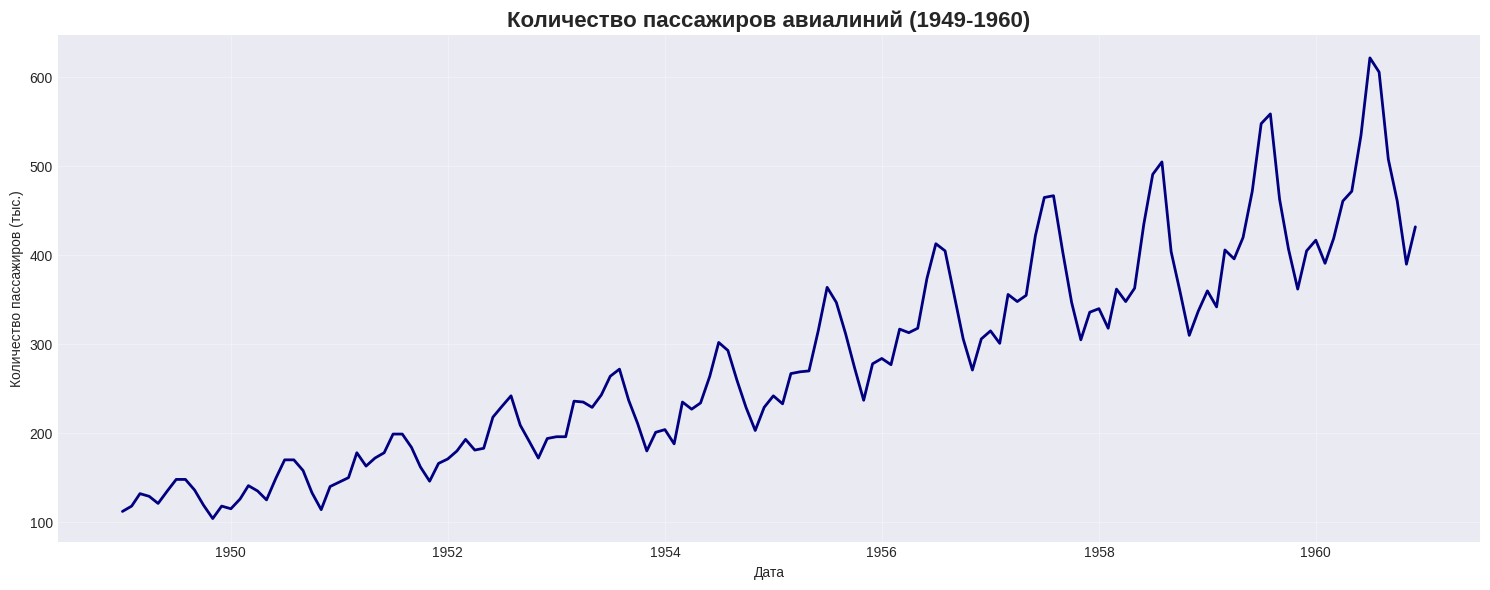

In [12]:
# Визуализация временного ряда
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(df.index, df['target'], linewidth=2, color='navy')
ax.set_title('Количество пассажиров авиалиний (1949-1960)', fontsize=16, fontweight='bold')
ax.set_xlabel('Дата')
ax.set_ylabel('Количество пассажиров (тыс.)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

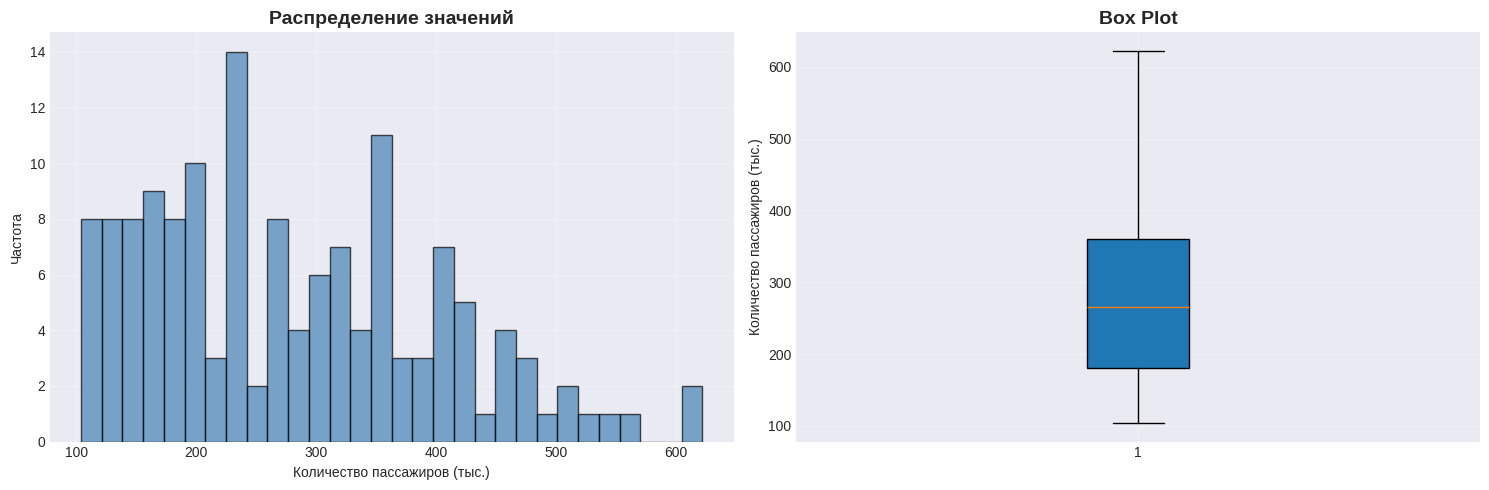

Асимметрия (Skewness): 0.5771
Эксцесс (Kurtosis): -0.3938


In [13]:
# Распределение значений
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.hist(df['target'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax1.set_title('Распределение значений', fontsize=14, fontweight='bold')
ax1.set_xlabel('Количество пассажиров (тыс.)')
ax1.set_ylabel('Частота')
ax1.grid(True, alpha=0.3)

ax2.boxplot(df['target'], patch_artist=True)
ax2.set_title('Box Plot', fontsize=14, fontweight='bold')
ax2.set_ylabel('Количество пассажиров (тыс.)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

from scipy.stats import skew, kurtosis
print(f'Асимметрия (Skewness): {skew(df["target"]):.4f}')
print(f'Эксцесс (Kurtosis): {kurtosis(df["target"]):.4f}')

## Декомпозиция временного ряда

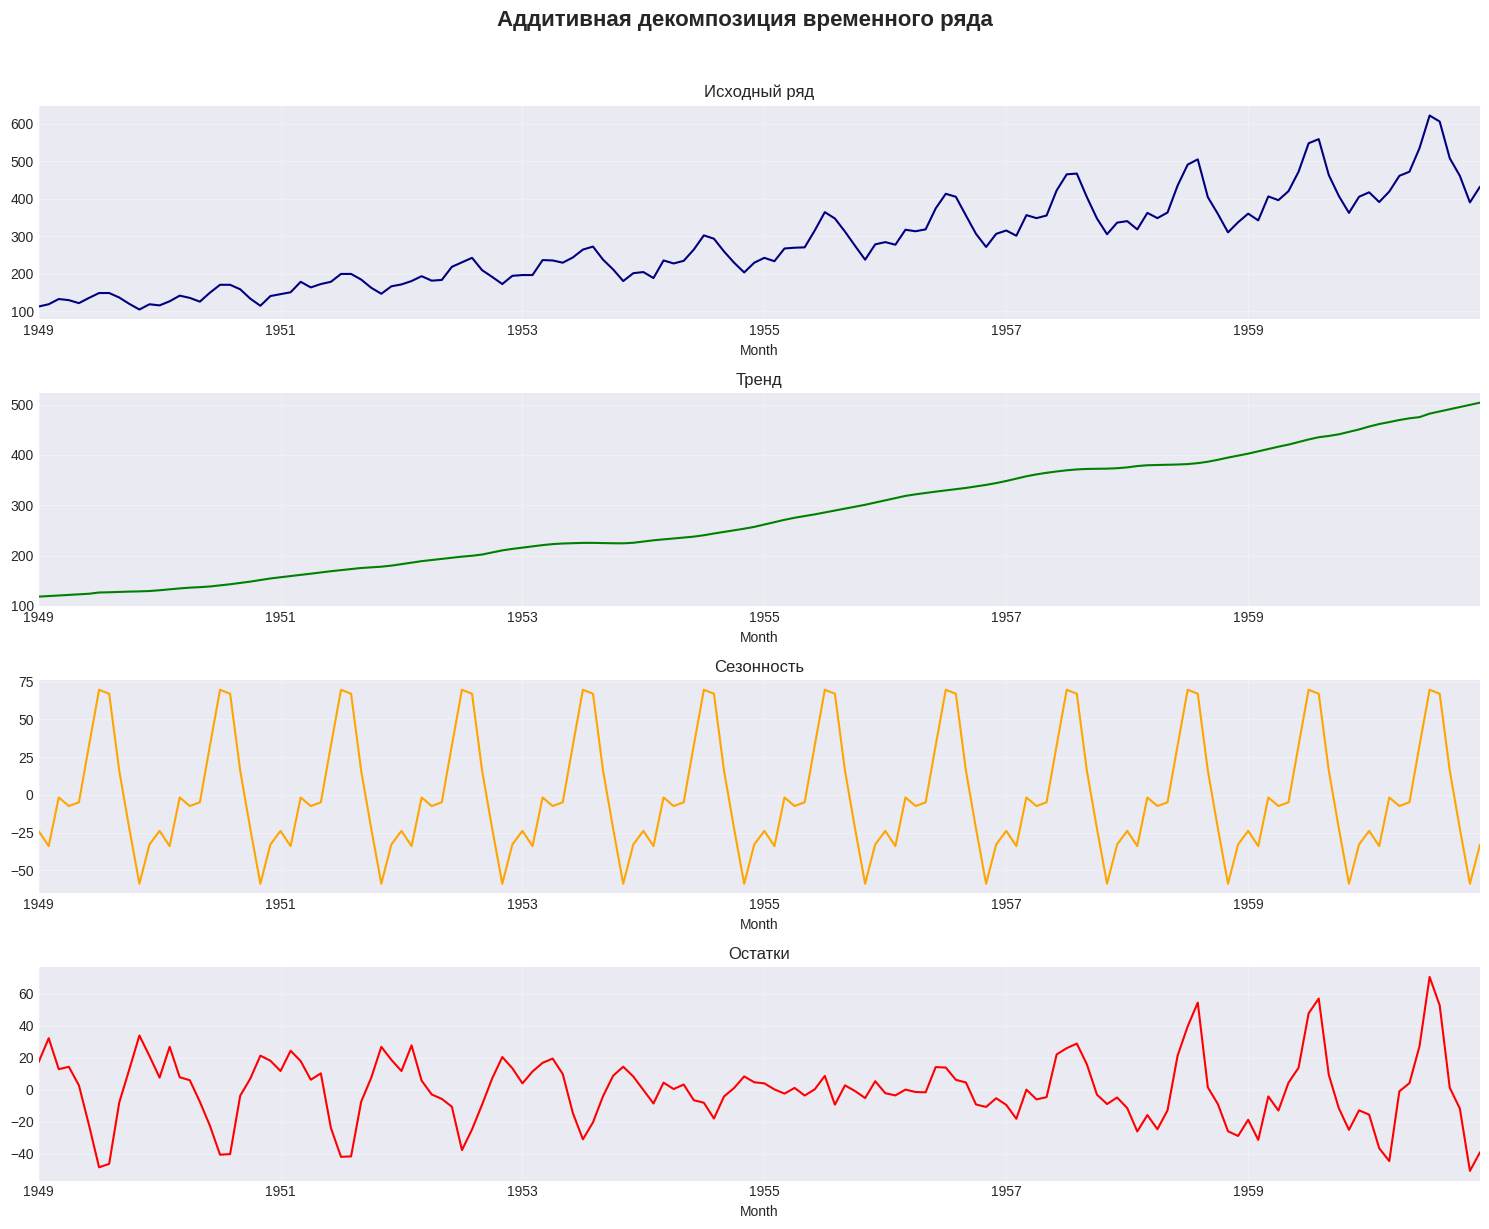

In [14]:
# Аддитивная декомпозиция
decomp = seasonal_decompose(df['target'], model='additive', period=12, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(15, 12))
decomp.observed.plot(ax=axes[0], title='Исходный ряд', color='navy')
axes[0].grid(True, alpha=0.3)
decomp.trend.plot(ax=axes[1], title='Тренд', color='green')
axes[1].grid(True, alpha=0.3)
decomp.seasonal.plot(ax=axes[2], title='Сезонность', color='orange')
axes[2].grid(True, alpha=0.3)
decomp.resid.plot(ax=axes[3], title='Остатки', color='red')
axes[3].grid(True, alpha=0.3)
plt.suptitle('Аддитивная декомпозиция временного ряда', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

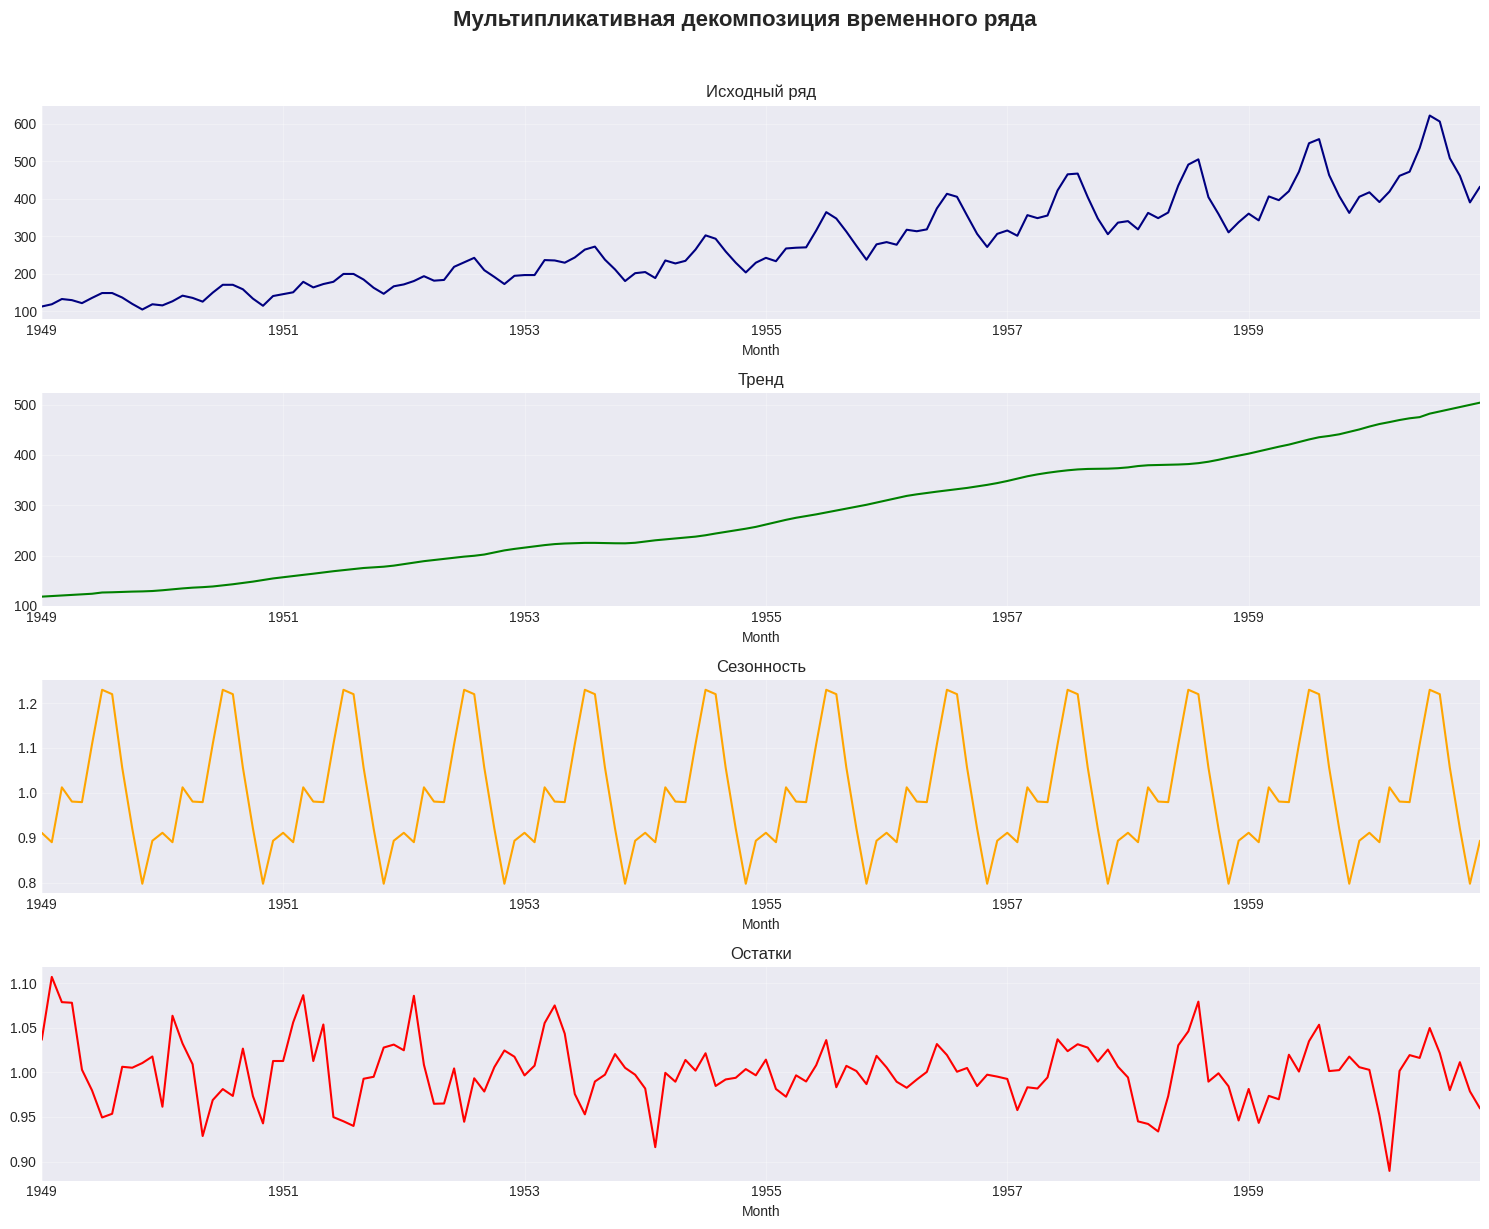

In [15]:
# Мультипликативная декомпозиция (для сравнения)
decomp_mul = seasonal_decompose(df['target'], model='multiplicative', period=12, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(15, 12))
decomp_mul.observed.plot(ax=axes[0], title='Исходный ряд', color='navy')
axes[0].grid(True, alpha=0.3)
decomp_mul.trend.plot(ax=axes[1], title='Тренд', color='green')
axes[1].grid(True, alpha=0.3)
decomp_mul.seasonal.plot(ax=axes[2], title='Сезонность', color='orange')
axes[2].grid(True, alpha=0.3)
decomp_mul.resid.plot(ax=axes[3], title='Остатки', color='red')
axes[3].grid(True, alpha=0.3)
plt.suptitle('Мультипликативная декомпозиция временного ряда', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Статистические свойства

### Стационарность

In [16]:
def test_stationarity(ts, title='Временной ряд'):
    print(f'\n{"="*60}')
    print(f'Тесты на стационарность: {title}')
    print(f'{"="*60}')

    # ADF
    adf = adfuller(ts.dropna(), autolag='AIC')
    print(f'\nADF Statistic: {adf[0]:.6f}')
    print(f'p-value: {adf[1]:.6f}')
    if adf[1] <= 0.05:
        print(f'✓ Ряд стационарен (p < 0.05)')
    else:
        print(f'✗ Ряд нестационарен (p > 0.05)')

    # KPSS
    kpss_result = kpss(ts.dropna(), regression='c', nlags='auto')
    print(f'\nKPSS Statistic: {kpss_result[0]:.6f}')
    print(f'p-value: {kpss_result[1]:.6f}')
    if kpss_result[1] >= 0.05:
        print(f'✓ Ряд стационарен (p >= 0.05)')
    else:
        print(f'✗ Ряд нестационарен (p < 0.05)')

test_stationarity(df['target'], 'Исходный ряд')


Тесты на стационарность: Исходный ряд

ADF Statistic: 0.815369
p-value: 0.991880
✗ Ряд нестационарен (p > 0.05)

KPSS Statistic: 1.651312
p-value: 0.010000
✗ Ряд нестационарен (p < 0.05)


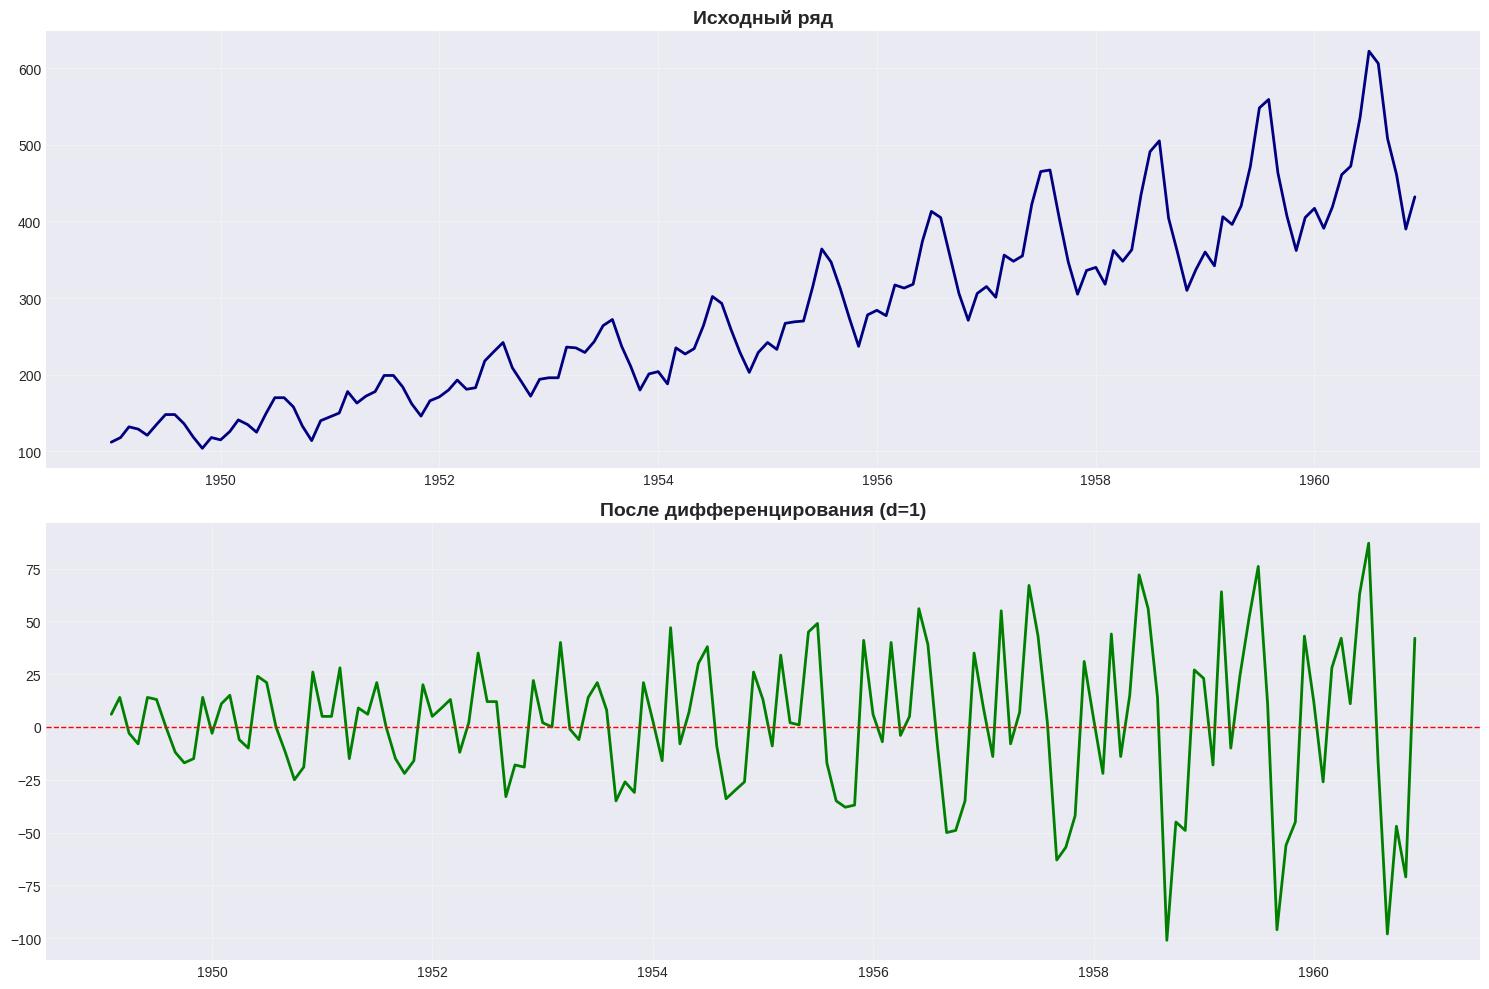


Тесты на стационарность: После дифференцирования (d=1)

ADF Statistic: -2.829267
p-value: 0.054213
✗ Ряд нестационарен (p > 0.05)

KPSS Statistic: 0.023898
p-value: 0.100000
✓ Ряд стационарен (p >= 0.05)


In [17]:
# Применяем дифференцирование для достижения стационарности
df['target_diff1'] = df['target'].diff()

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

axes[0].plot(df.index, df['target'], color='navy', linewidth=2)
axes[0].set_title('Исходный ряд', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df.index, df['target_diff1'], color='green', linewidth=2)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('После дифференцирования (d=1)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

test_stationarity(df['target_diff1'], 'После дифференцирования (d=1)')

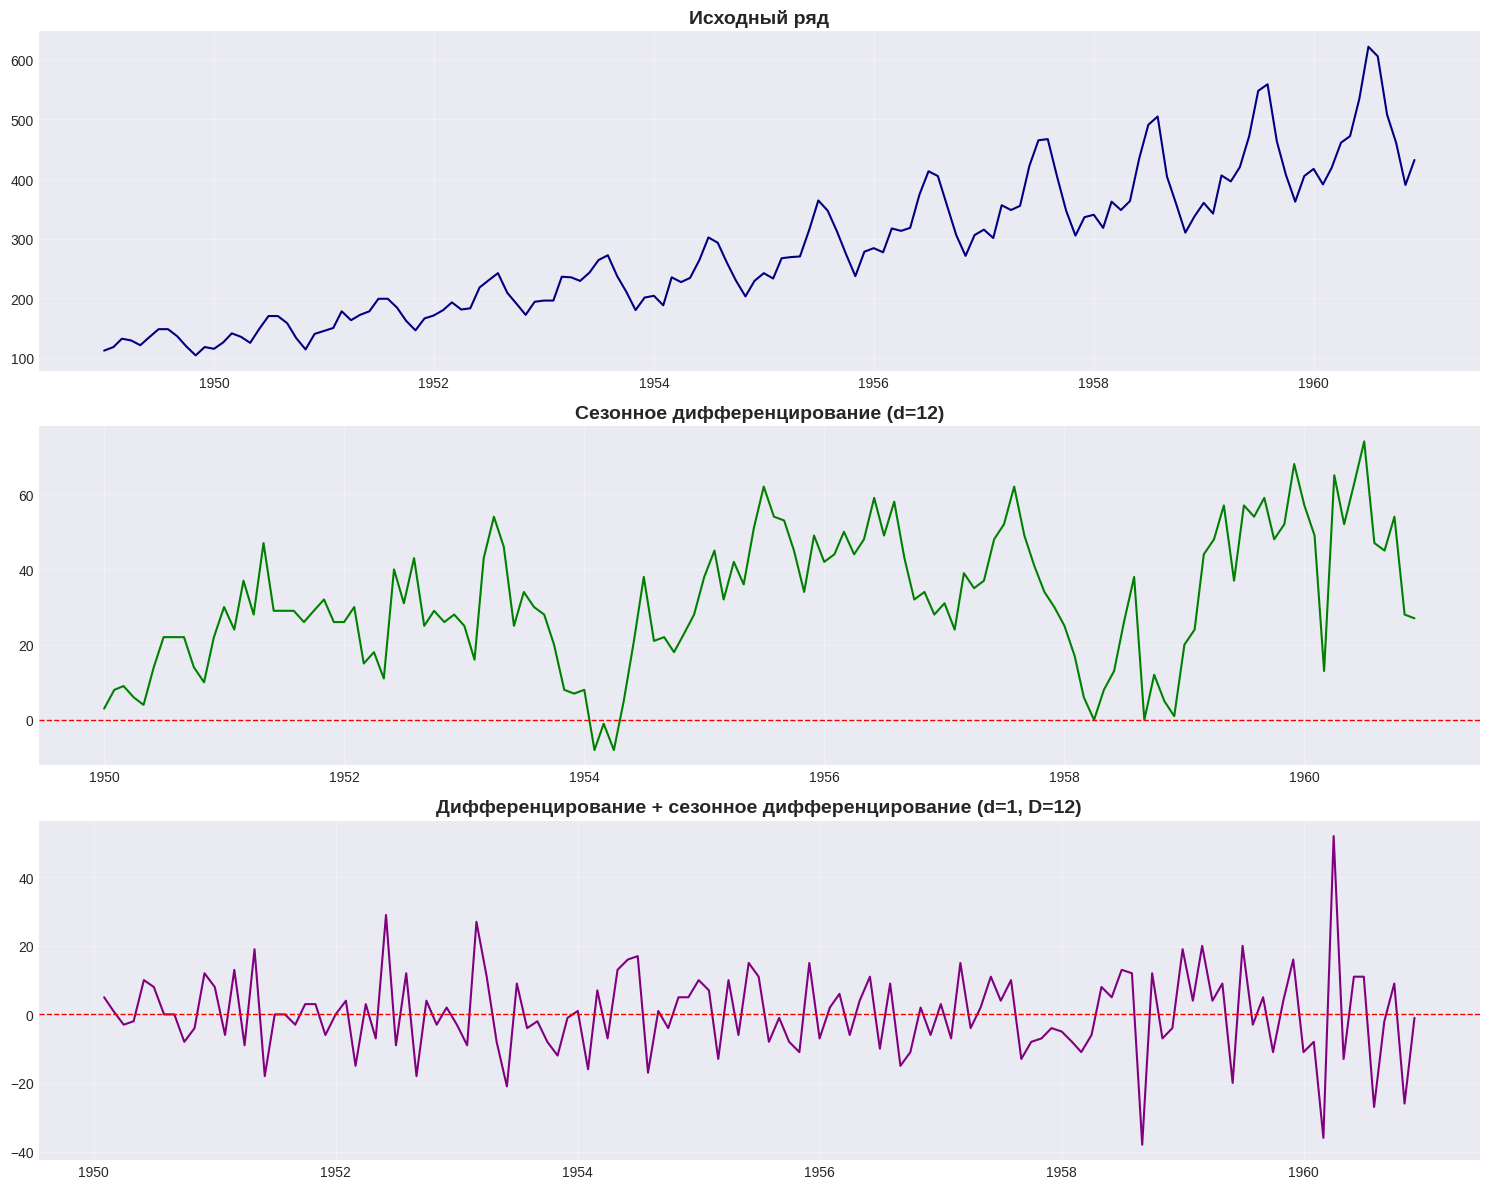


Тесты на стационарность: После (1,12) дифференцирования

ADF Statistic: -15.595618
p-value: 0.000000
✓ Ряд стационарен (p < 0.05)

KPSS Statistic: 0.046774
p-value: 0.100000
✓ Ряд стационарен (p >= 0.05)


In [18]:
# Сезонное дифференцирование
df['target_diff12'] = df['target'].diff(12)
df['target_diff1_diff12'] = df['target_diff1'].diff(12)

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

axes[0].plot(df.index, df['target'], color='navy', linewidth=1.5)
axes[0].set_title('Исходный ряд', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df.index, df['target_diff12'], color='green', linewidth=1.5)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Сезонное дифференцирование (d=12)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].plot(df.index, df['target_diff1_diff12'], color='purple', linewidth=1.5)
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[2].set_title('Дифференцирование + сезонное дифференцирование (d=1, D=12)', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

test_stationarity(df['target_diff1_diff12'], 'После (1,12) дифференцирования')

### Автокорреляция (ACF) и частичная автокорреляция (PACF)

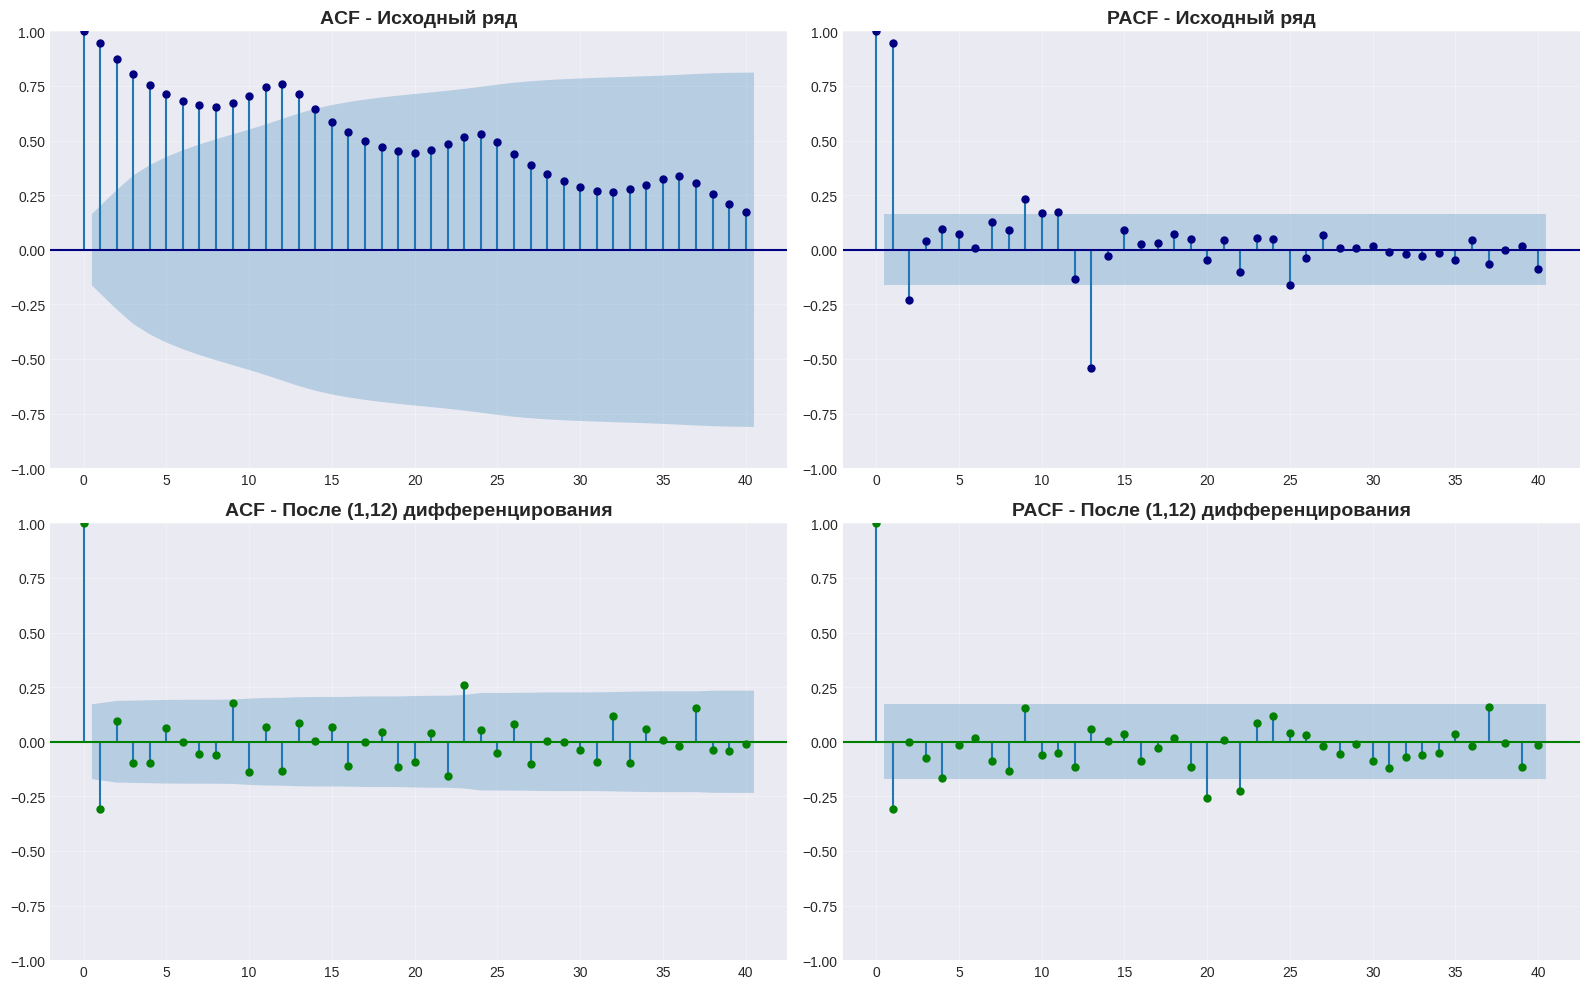

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Исходный ряд
plot_acf(df['target'], lags=40, ax=axes[0, 0], color='navy')
axes[0, 0].set_title('ACF - Исходный ряд', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

plot_pacf(df['target'], lags=40, ax=axes[0, 1], method='ywm', color='navy')
axes[0, 1].set_title('PACF - Исходный ряд', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# После дифференцирования
plot_acf(df['target_diff1_diff12'].dropna(), lags=40, ax=axes[1, 0], color='green')
axes[1, 0].set_title('ACF - После (1,12) дифференцирования', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

plot_pacf(df['target_diff1_diff12'].dropna(), lags=40, ax=axes[1, 1], method='ywm', color='green')
axes[1, 1].set_title('PACF - После (1,12) дифференцирования', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Data Preparation

### Feature Engineering

In [20]:
# Создаем датафрейм с признаками
df_features = df[['target']].copy()

# 1. Лаговые признаки
for lag in range(1, 13):
    df_features[f'lag_{lag}'] = df_features['target'].shift(lag)

# 2. Скользящие статистики
for window in [3, 6, 12]:
    df_features[f'rolling_mean_{window}'] = df_features['target'].rolling(window=window).mean()
    df_features[f'rolling_std_{window}'] = df_features['target'].rolling(window=window).std()

# 3. Календарные признаки
df_features['month'] = df_features.index.month
df_features['quarter'] = df_features.index.quarter
df_features['year'] = df_features.index.year

# 4. Циклические признаки
df_features['month_sin'] = np.sin(2 * np.pi * df_features['month'] / 12)
df_features['month_cos'] = np.cos(2 * np.pi * df_features['month'] / 12)
df_features['quarter_sin'] = np.sin(2 * np.pi * df_features['quarter'] / 4)
df_features['quarter_cos'] = np.cos(2 * np.pi * df_features['quarter'] / 4)

# Удаляем пропуски
df_features_clean = df_features.dropna()

print(f'Исходный размер: {df_features.shape}')
print(f'После удаления NaN: {df_features_clean.shape}')
print(f'Созданные признаки: {df_features_clean.shape[1]} столбцов')
print(f'\nСписок признаков:')
print(list(df_features_clean.columns))

Исходный размер: (144, 26)
После удаления NaN: (132, 26)
Созданные признаки: 26 столбцов

Список признаков:
['target', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'rolling_mean_3', 'rolling_std_3', 'rolling_mean_6', 'rolling_std_6', 'rolling_mean_12', 'rolling_std_12', 'month', 'quarter', 'year', 'month_sin', 'month_cos', 'quarter_sin', 'quarter_cos']


## Разделение на train/test

Train: (105, 26)
Период: 1950-01-01 00:00:00 - 1958-09-01 00:00:00

Test: (27, 26)
Период: 1958-10-01 00:00:00 - 1960-12-01 00:00:00


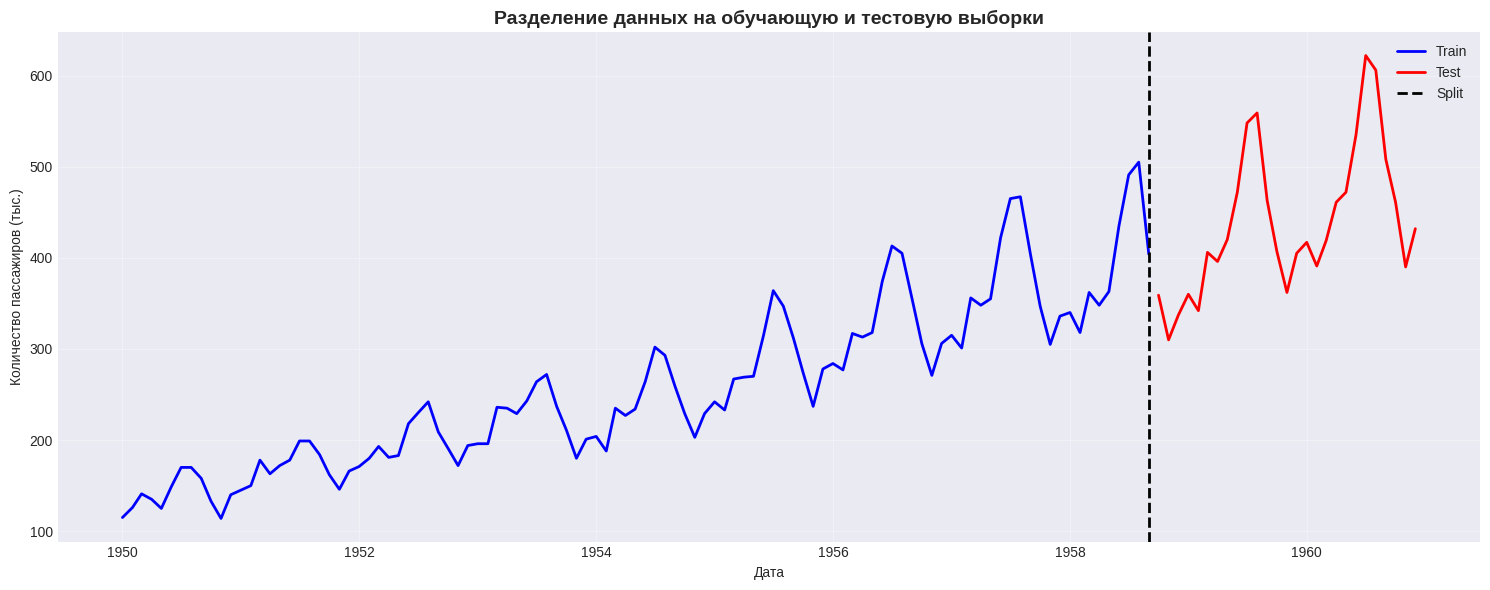

In [21]:
# Разделение с сохранением временной последовательности
train_size = int(len(df_features_clean) * 0.8)
train_data = df_features_clean.iloc[:train_size]
test_data = df_features_clean.iloc[train_size:]

print(f'Train: {train_data.shape}')
print(f'Период: {train_data.index.min()} - {train_data.index.max()}')
print(f'\nTest: {test_data.shape}')
print(f'Период: {test_data.index.min()} - {test_data.index.max()}')

# Подготовка X и y
X_train = train_data.drop('target', axis=1)
y_train = train_data['target']
X_test = test_data.drop('target', axis=1)
y_test = test_data['target']

# Визуализация разделения
plt.figure(figsize=(15, 6))
plt.plot(train_data.index, train_data['target'], label='Train', linewidth=2, color='blue')
plt.plot(test_data.index, test_data['target'], label='Test', linewidth=2, color='red')
plt.axvline(x=train_data.index[-1], color='black', linestyle='--', linewidth=2, label='Split')
plt.title('Разделение данных на обучающую и тестовую выборки', fontsize=14, fontweight='bold')
plt.xlabel('Дата')
plt.ylabel('Количество пассажиров (тыс.)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Modeling

### Baseline модели

In [22]:
predictions_dict = {}

# 1. Naive Forecast
naive_pred = np.full(len(y_test), y_train.iloc[-1])
predictions_dict['Naive'] = naive_pred

# 2. Seasonal Naive (период = 12)
seasonal_naive_pred = []
for i in range(len(y_test)):
    if i < 12:
        seasonal_naive_pred.append(y_train.iloc[-(12-i)])
    else:
        seasonal_naive_pred.append(seasonal_naive_pred[i-12])
predictions_dict['Seasonal Naive'] = np.array(seasonal_naive_pred)

# 3. Moving Average (окно = 12)
ma_pred = np.full(len(y_test), y_train.tail(12).mean())
predictions_dict['Moving Average'] = ma_pred

print('✓ Baseline модели построены')
print(f'Naive: {naive_pred[0]:.1f}')
print(f'Seasonal Naive: {seasonal_naive_pred[0]:.1f}')
print(f'Moving Average: {ma_pred[0]:.1f}')

✓ Baseline модели построены
Naive: 404.0
Seasonal Naive: 347.0
Moving Average: 379.5


### Статистические модели

In [23]:
# 4. ARIMA
try:
    arima_model = ARIMA(y_train, order=(1, 1, 1))
    arima_fitted = arima_model.fit()
    arima_pred = arima_fitted.forecast(steps=len(y_test))
    predictions_dict['ARIMA'] = arima_pred.values
    print(f'✓ ARIMA обучена (AIC: {arima_fitted.aic:.2f})')
except Exception as e:
    print(f'ARIMA ошибка: {e}')
    predictions_dict['ARIMA'] = np.full(len(y_test), y_train.mean())

✓ ARIMA обучена (AIC: 985.80)


In [24]:
# 5. SARIMA
try:
    sarima_model = SARIMAX(y_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
    sarima_fitted = sarima_model.fit(disp=False)
    sarima_pred = sarima_fitted.forecast(steps=len(y_test))
    predictions_dict['SARIMA'] = sarima_pred.values
    print(f'✓ SARIMA обучена (AIC: {sarima_fitted.aic:.2f})')
except Exception as e:
    print(f'SARIMA ошибка: {e}')
    predictions_dict['SARIMA'] = np.full(len(y_test), y_train.mean())

✓ SARIMA обучена (AIC: 702.57)


In [25]:
# 6. Holt-Winters (Exponential Smoothing)
try:
    hw_model = ExponentialSmoothing(y_train, seasonal_periods=12, trend='add', seasonal='add')
    hw_fitted = hw_model.fit()
    hw_pred = hw_fitted.forecast(steps=len(y_test))
    predictions_dict['Holt-Winters'] = hw_pred.values
    print(f'✓ Holt-Winters обучена')
except Exception as e:
    print(f'Holt-Winters ошибка: {e}')
    predictions_dict['Holt-Winters'] = np.full(len(y_test), y_train.mean())

✓ Holt-Winters обучена


## Машинное обучение

In [26]:
# 7. Linear Regression
try:
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    lr_pred = lr_model.predict(X_test)
    predictions_dict['Linear Regression'] = lr_pred
    print(f'✓ Linear Regression обучена (R² train: {lr_model.score(X_train, y_train):.4f})')
except Exception as e:
    print(f'Linear Regression ошибка: {e}')
    predictions_dict['Linear Regression'] = np.full(len(y_test), y_train.mean())

✓ Linear Regression обучена (R² train: 1.0000)


In [27]:
# 8. Random Forest
try:
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)
    rf_pred = rf_model.predict(X_test)
    predictions_dict['Random Forest'] = rf_pred
    print(f'✓ Random Forest обучен (R² train: {rf_model.score(X_train, y_train):.4f})')
except Exception as e:
    print(f'Random Forest ошибка: {e}')
    predictions_dict['Random Forest'] = np.full(len(y_test), y_train.mean())

✓ Random Forest обучен (R² train: 0.9950)


In [28]:
# 9. Gradient Boosting
try:
    gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
    gb_model.fit(X_train, y_train)
    gb_pred = gb_model.predict(X_test)
    predictions_dict['Gradient Boosting'] = gb_pred
    print(f'✓ Gradient Boosting обучен (R² train: {gb_model.score(X_train, y_train):.4f})')
except Exception as e:
    print(f'Gradient Boosting ошибка: {e}')
    predictions_dict['Gradient Boosting'] = np.full(len(y_test), y_train.mean())

✓ Gradient Boosting обучен (R² train: 1.0000)


## Дополнительно: LSTM

In [29]:
# Попробуем LSTM
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout

    # Масштабирование
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(y_train.values.reshape(-1, 1))
    test_scaled = scaler.transform(y_test.values.reshape(-1, 1))

    # Создание последовательностей
    def create_sequences(data, seq_length):
        xs, ys = [], []
        for i in range(len(data) - seq_length):
            x = data[i:i+seq_length]
            y = data[i+seq_length]
            xs.append(x)
            ys.append(y)
        return np.array(xs), np.array(ys)

    seq_length = 12
    X_train_lstm, y_train_lstm = create_sequences(train_scaled, seq_length)

    # Строим модель
    lstm_model = Sequential([
        LSTM(50, activation='relu', return_sequences=True, input_shape=(seq_length, 1)),
        Dropout(0.2),
        LSTM(50, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])

    lstm_model.compile(optimizer='adam', loss='mse')

    # Обучение
    history = lstm_model.fit(X_train_lstm, y_train_lstm, epochs=50, batch_size=32,
                              validation_split=0.2, verbose=0)

    # Прогноз
    X_test_lstm, y_test_lstm = create_sequences(test_scaled, seq_length)
    lstm_pred_scaled = lstm_model.predict(X_test_lstm, verbose=0)
    lstm_pred = scaler.inverse_transform(lstm_pred_scaled)

    # Дополняем до длины y_test (добавляем среднее для первых seq_length значений)
    full_lstm_pred = np.full(len(y_test), y_train.mean())
    full_lstm_pred[seq_length:] = lstm_pred.flatten()
    predictions_dict['LSTM'] = full_lstm_pred
    print(f'✓ LSTM обучена (последняя loss: {history.history["loss"][-1]:.4f})')

except Exception as e:
    print(f'LSTM не выполнена: {e}')
    predictions_dict['LSTM'] = np.full(len(y_test), y_train.mean())

✓ LSTM обучена (последняя loss: 0.0089)


## Evaluation

In [30]:
def calculate_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)

    return {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'R²': r2
    }

# Расчет метрик для всех моделей
metrics_list = []
for model_name, pred in predictions_dict.items():
    if len(pred) == len(y_test):
        metrics = calculate_metrics(y_test.values, pred, model_name)
        metrics_list.append(metrics)

metrics_df = pd.DataFrame(metrics_list).sort_values('RMSE')


print('СРАВНЕНИЕ МОДЕЛЕЙ ПО МЕТРИКАМ КАЧЕСТВА')

print(metrics_df.to_string(index=False))


СРАВНЕНИЕ МОДЕЛЕЙ ПО МЕТРИКАМ КАЧЕСТВА
            Model          MAE          MSE         RMSE         MAPE        R²
Linear Regression 1.467402e-12 2.289945e-24 1.513256e-12 3.342908e-13  1.000000
     Holt-Winters 2.151822e+01 7.067986e+02 2.658568e+01 4.601578e+00  0.888724
Gradient Boosting 3.564541e+01 2.239785e+03 4.732636e+01 7.663357e+00  0.647375
    Random Forest 3.242259e+01 2.242944e+03 4.735973e+01 6.652916e+00  0.646878
           SARIMA 5.955044e+01 4.596771e+03 6.779949e+01 1.310785e+01  0.276298
   Seasonal Naive 6.533333e+01 5.482667e+03 7.404503e+01 1.431503e+01  0.136825
            Naive 6.407407e+01 7.594963e+03 8.714908e+01 1.354528e+01 -0.195728
   Moving Average 7.509259e+01 9.922917e+03 9.961384e+01 1.547123e+01 -0.562234
            ARIMA 7.507835e+01 1.000831e+04 1.000415e+02 1.544654e+01 -0.575678
             LSTM 9.982291e+01 1.679589e+04 1.295990e+02 2.191593e+01 -1.644295


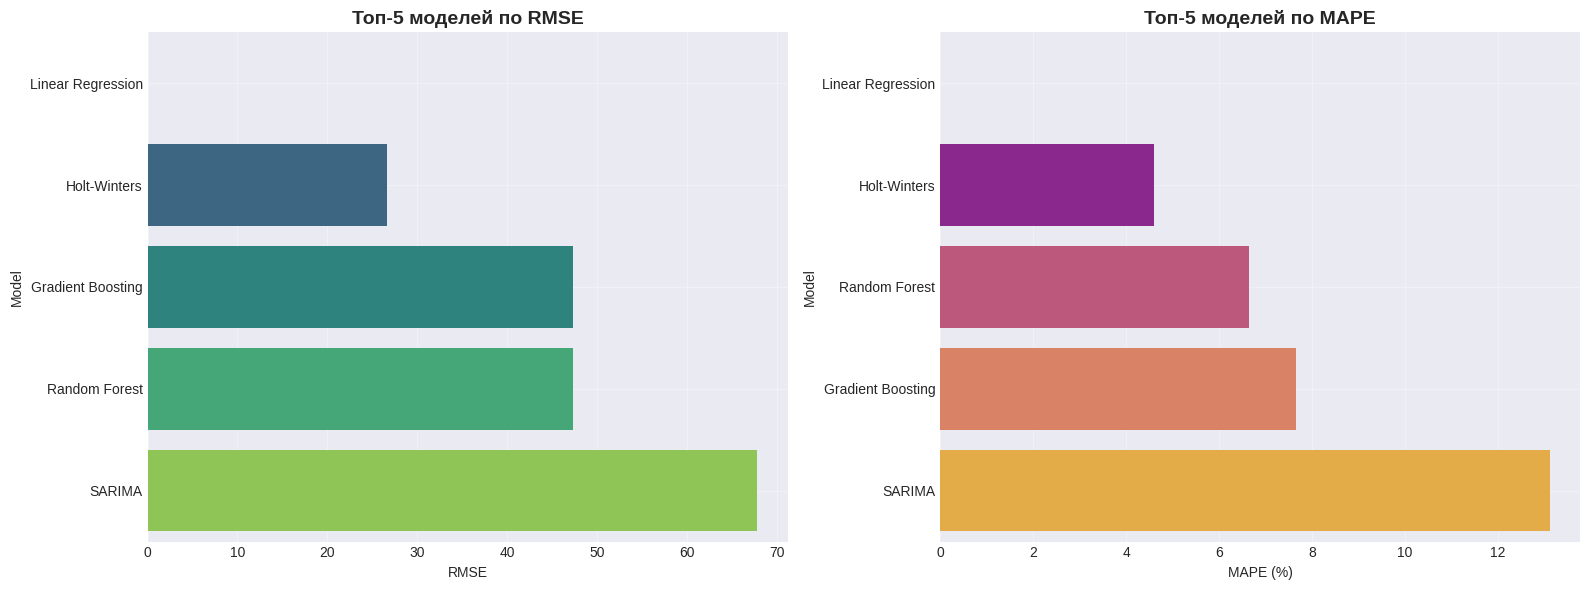

In [31]:
# Визуализация сравнения моделей
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# RMSE
top_models = metrics_df.nsmallest(5, 'RMSE')
sns.barplot(x='RMSE', y='Model', data=top_models, ax=ax1, palette='viridis')
ax1.set_title('Топ-5 моделей по RMSE', fontsize=14, fontweight='bold')
ax1.set_xlabel('RMSE')
ax1.grid(True, alpha=0.3)

# MAPE
top_models_mape = metrics_df.nsmallest(5, 'MAPE')
sns.barplot(x='MAPE', y='Model', data=top_models_mape, ax=ax2, palette='plasma')
ax2.set_title('Топ-5 моделей по MAPE', fontsize=14, fontweight='bold')
ax2.set_xlabel('MAPE (%)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

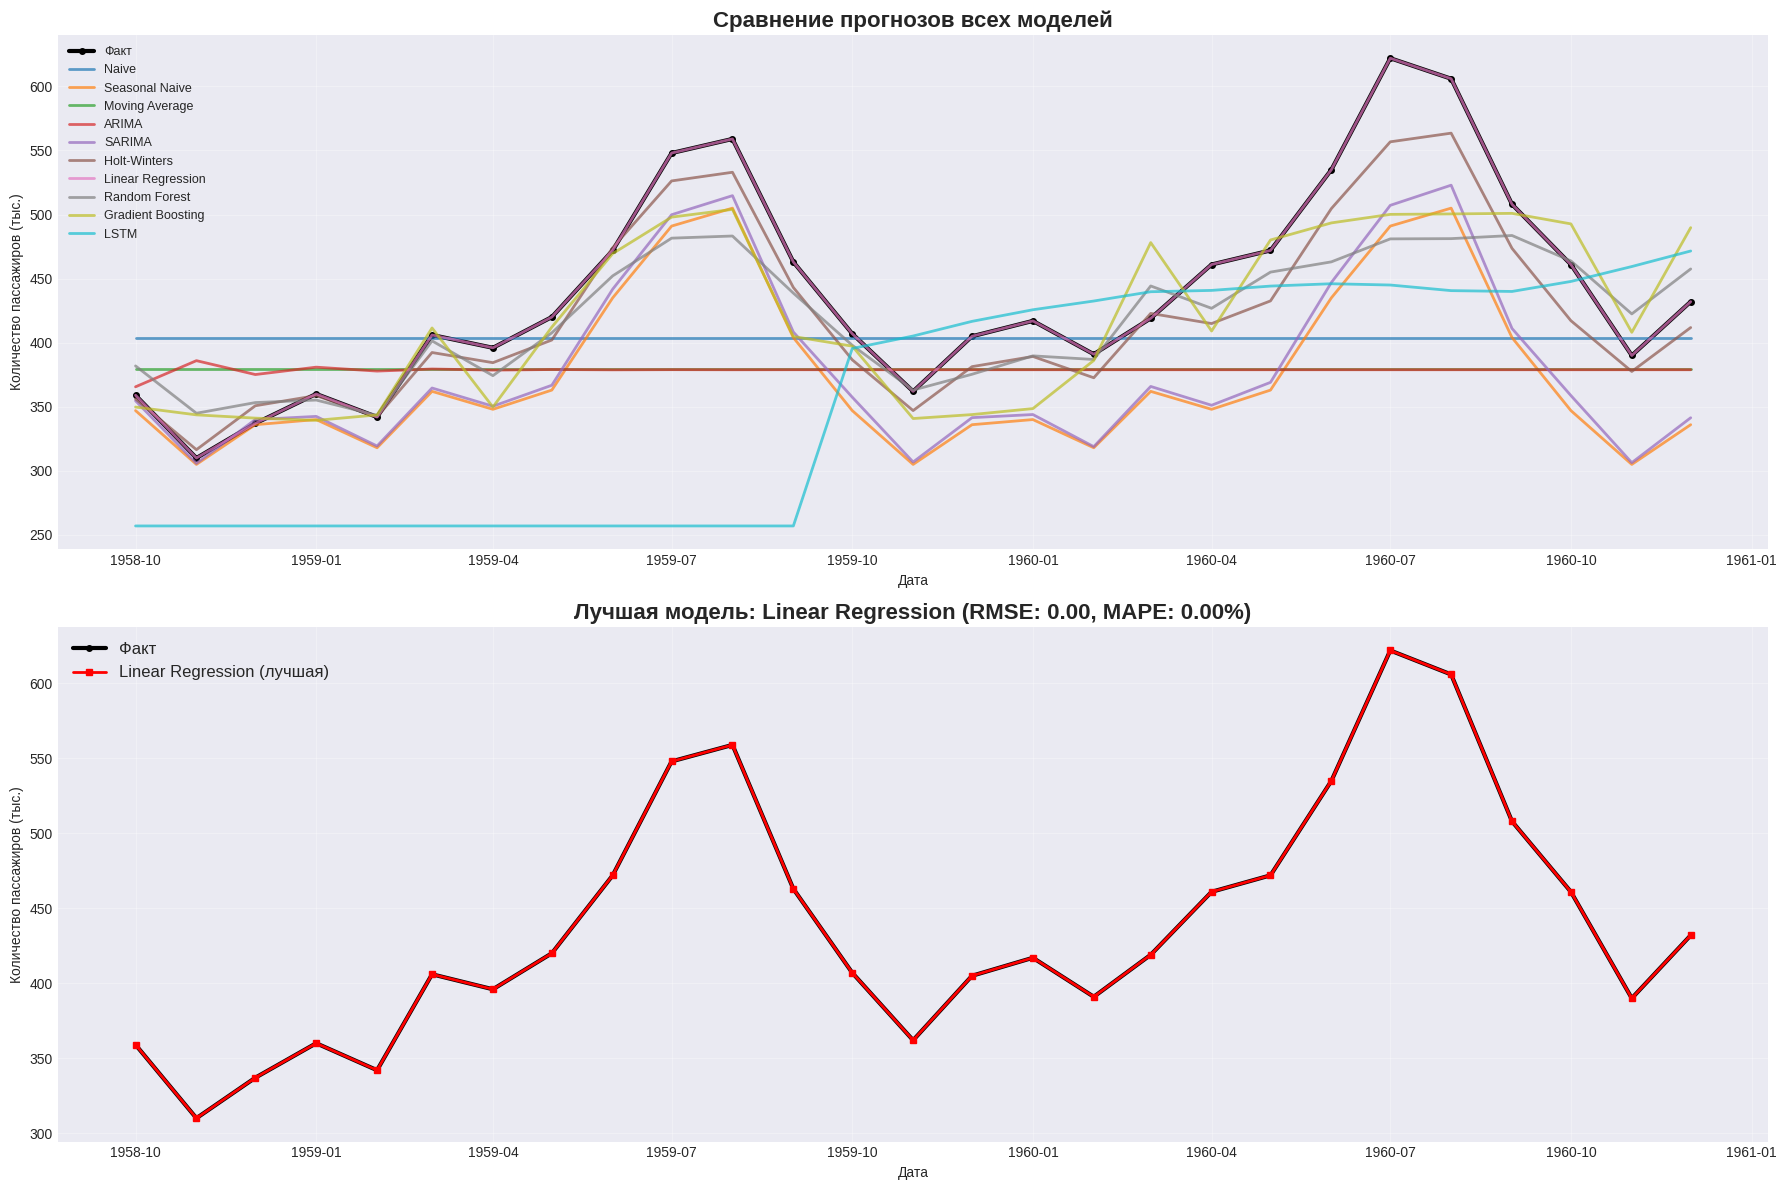

In [32]:
# Визуализация всех прогнозов
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12))

# Все модели
ax1.plot(y_test.index, y_test.values, label='Факт', linewidth=3, color='black', marker='o', markersize=4)

colors = plt.cm.tab10(np.linspace(0, 1, len(predictions_dict)))
for (model_name, pred), color in zip(predictions_dict.items(), colors):
    if len(pred) == len(y_test):
        ax1.plot(y_test.index, pred, label=model_name, linewidth=2, alpha=0.7, color=color)

ax1.set_title('Сравнение прогнозов всех моделей', fontsize=16, fontweight='bold')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество пассажиров (тыс.)')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# Лучшая модель
best_model = metrics_df.iloc[0]['Model']
best_pred = predictions_dict[best_model]

ax2.plot(y_test.index, y_test.values, label='Факт', linewidth=3, color='black', marker='o', markersize=4)
ax2.plot(y_test.index, best_pred, label=f'{best_model} (лучшая)', linewidth=2,
         color='red', marker='s', markersize=4)
ax2.fill_between(y_test.index, y_test.values, best_pred, alpha=0.2, color='red')

ax2.set_title(f'Лучшая модель: {best_model} (RMSE: {metrics_df.iloc[0]["RMSE"]:.2f}, MAPE: {metrics_df.iloc[0]["MAPE"]:.2f}%)',
              fontsize=16, fontweight='bold')
ax2.set_xlabel('Дата')
ax2.set_ylabel('Количество пассажиров (тыс.)')
ax2.legend(loc='upper left', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()